In [119]:
from pathlib import Path
import h5py

# define path
data_dir = Path('/mnt/c/Group_project/ne_data')
# find out all nxspe files
nxspe_files = list(data_dir.glob("*.nxspe"))

print(f"Find {len(nxspe_files)} files in content:")
for i, f in enumerate(nxspe_files):
    print(f"{i}: {f.name}")

# read first files as an example load incoherent
if nxspe_files:
    target_file = nxspe_files[1]
    with h5py.File(target_file, 'r') as f:
        # read data 
        data = f['__MSL____PLET_benzene_290K_1.24meV_inc_rings/data/data'][()]
        print(f"\n Loaded {target_file.name}, Matrix size: {data.shape}")

Find 8 files in content:
0: benzene_290_124_coh.nxspe
1: benzene_290_124_inc.nxspe
2: benzene_290_197_coh.nxspe
3: benzene_290_197_inc.nxspe
4: benzene_290_360_coh.nxspe
5: benzene_290_360_inc.nxspe
6: benzene_290_861_coh.nxspe
7: benzene_290_861_inc.nxspe

 Loaded benzene_290_124_inc.nxspe, Matrix size: (249, 320)


In [120]:
import h5py
from pathlib import Path

# use route
data_dir = Path('/mnt/c/Group_project/ne_data')
nxspe_files = list(data_dir.glob("*.nxspe"))

if nxspe_files:
    target_file = nxspe_files[1] # use inc

    print(f"checking file structure: {target_file.name}\n")
    
    with h5py.File(target_file, 'r') as f:
        # define a function to find the file
        def print_structure(name, obj):
            if isinstance(obj, h5py.Dataset):
                # as long as it's a datasets, print out the name
                print(f"Route: {name:40} | Dimension: {obj.shape} | Type: {obj.dtype}")


        f.visititems(print_structure) # print every file structures

checking file structure: benzene_290_124_inc.nxspe

Route: __MSL____PLET_benzene_290K_1.24meV_inc_rings/NXSPE_info/fixed_energy | Dimension: (1,) | Type: float64
Route: __MSL____PLET_benzene_290K_1.24meV_inc_rings/NXSPE_info/ki_over_kf_scaling | Dimension: (1,) | Type: int32
Route: __MSL____PLET_benzene_290K_1.24meV_inc_rings/NXSPE_info/psi | Dimension: (1,) | Type: float64
Route: __MSL____PLET_benzene_290K_1.24meV_inc_rings/data/azimuthal | Dimension: (212,) | Type: float64
Route: __MSL____PLET_benzene_290K_1.24meV_inc_rings/data/azimuthal_width | Dimension: (212,) | Type: float64
Route: __MSL____PLET_benzene_290K_1.24meV_inc_rings/data/data | Dimension: (249, 320) | Type: float64
Route: __MSL____PLET_benzene_290K_1.24meV_inc_rings/data/distance | Dimension: (212,) | Type: float64
Route: __MSL____PLET_benzene_290K_1.24meV_inc_rings/data/energy | Dimension: (321,) | Type: float64
Route: __MSL____PLET_benzene_290K_1.24meV_inc_rings/data/error | Dimension: (249, 320) | Type: float64
Rout

In [122]:
# data we needed
import matplotlib.pyplot as plt
import numpy as np
import scipp as sc
file_path = target_file
with h5py.File(file_path, 'r') as f:
    data = f['__MSL____PLET_benzene_290K_1.24meV_inc_rings/data/data'][()] 
    energy = f['__MSL____PLET_benzene_290K_1.24meV_inc_rings/data/energy'][()]
    angles = f['__MSL____PLET_benzene_290K_1.24meV_inc_rings/data/polar'][()]
    ei = f['__MSL____PLET_benzene_290K_1.24meV_inc_rings/NXSPE_info/fixed_energy'][()]
    errors = f['__MSL____PLET_benzene_290K_1.24meV_inc_rings/data/error'][()]

In [123]:
data_vals= data[37:, :]
data_vals.shape

(212, 320)

In [124]:
error_vals = errors[37:, :]
error_vals.shape

(212, 320)

In [125]:
energy_bins= energy[:-1]
energy_bins.shape

(320,)

In [126]:
polar_angles=angles
polar_angles.shape

(212,)

Success! Built Scipp DataArray:
<scipp.DataArray>
Dimensions: Sizes[polar:212, energy:320, ]
Coordinates:
* energy                    float64            [meV]  (energy)  [-0.992, -0.9858, ..., 0.9796, 0.9858]
* polar                     float64            [deg]  (polar)  [19.1989, 19.659, ..., 133.699, 134.16]
Data:
                            float64         [counts]  (polar, energy)  [nan, nan, ..., 0, 0]  [nan, nan, ..., 0, 0]




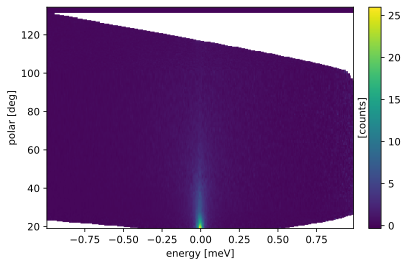

In [127]:
data_vals= data[37:, :]


da = sc.DataArray(
        data=sc.array(dims=['polar', 'energy'], values=data_vals, unit='counts', variances=error_vals**2),
        coords={
            'energy': sc.array(dims=['energy'], values=energy_bins, unit='meV'),
            'polar': sc.array(dims=['polar'], values=polar_angles, unit='deg')
        }
    )

print("Success! Built Scipp DataArray:")
print(da)

da.plot()

In [128]:
print(da.coords)

if 'Q' in da.coords:
    print("Q value range from:", da.coords['Q'].min(), "to", da.coords['Q'].max())
else:
    print("No Q values, check again")

<scipp.Dict>
  energy: <scipp.Variable> (energy: 320)    float64            [meV]  [-0.992, -0.9858, ..., 0.9796, 0.9858]
  polar: <scipp.Variable> (polar: 212)    float64            [deg]  [19.1989, 19.659, ..., 133.699, 134.16]

No Q values, check again


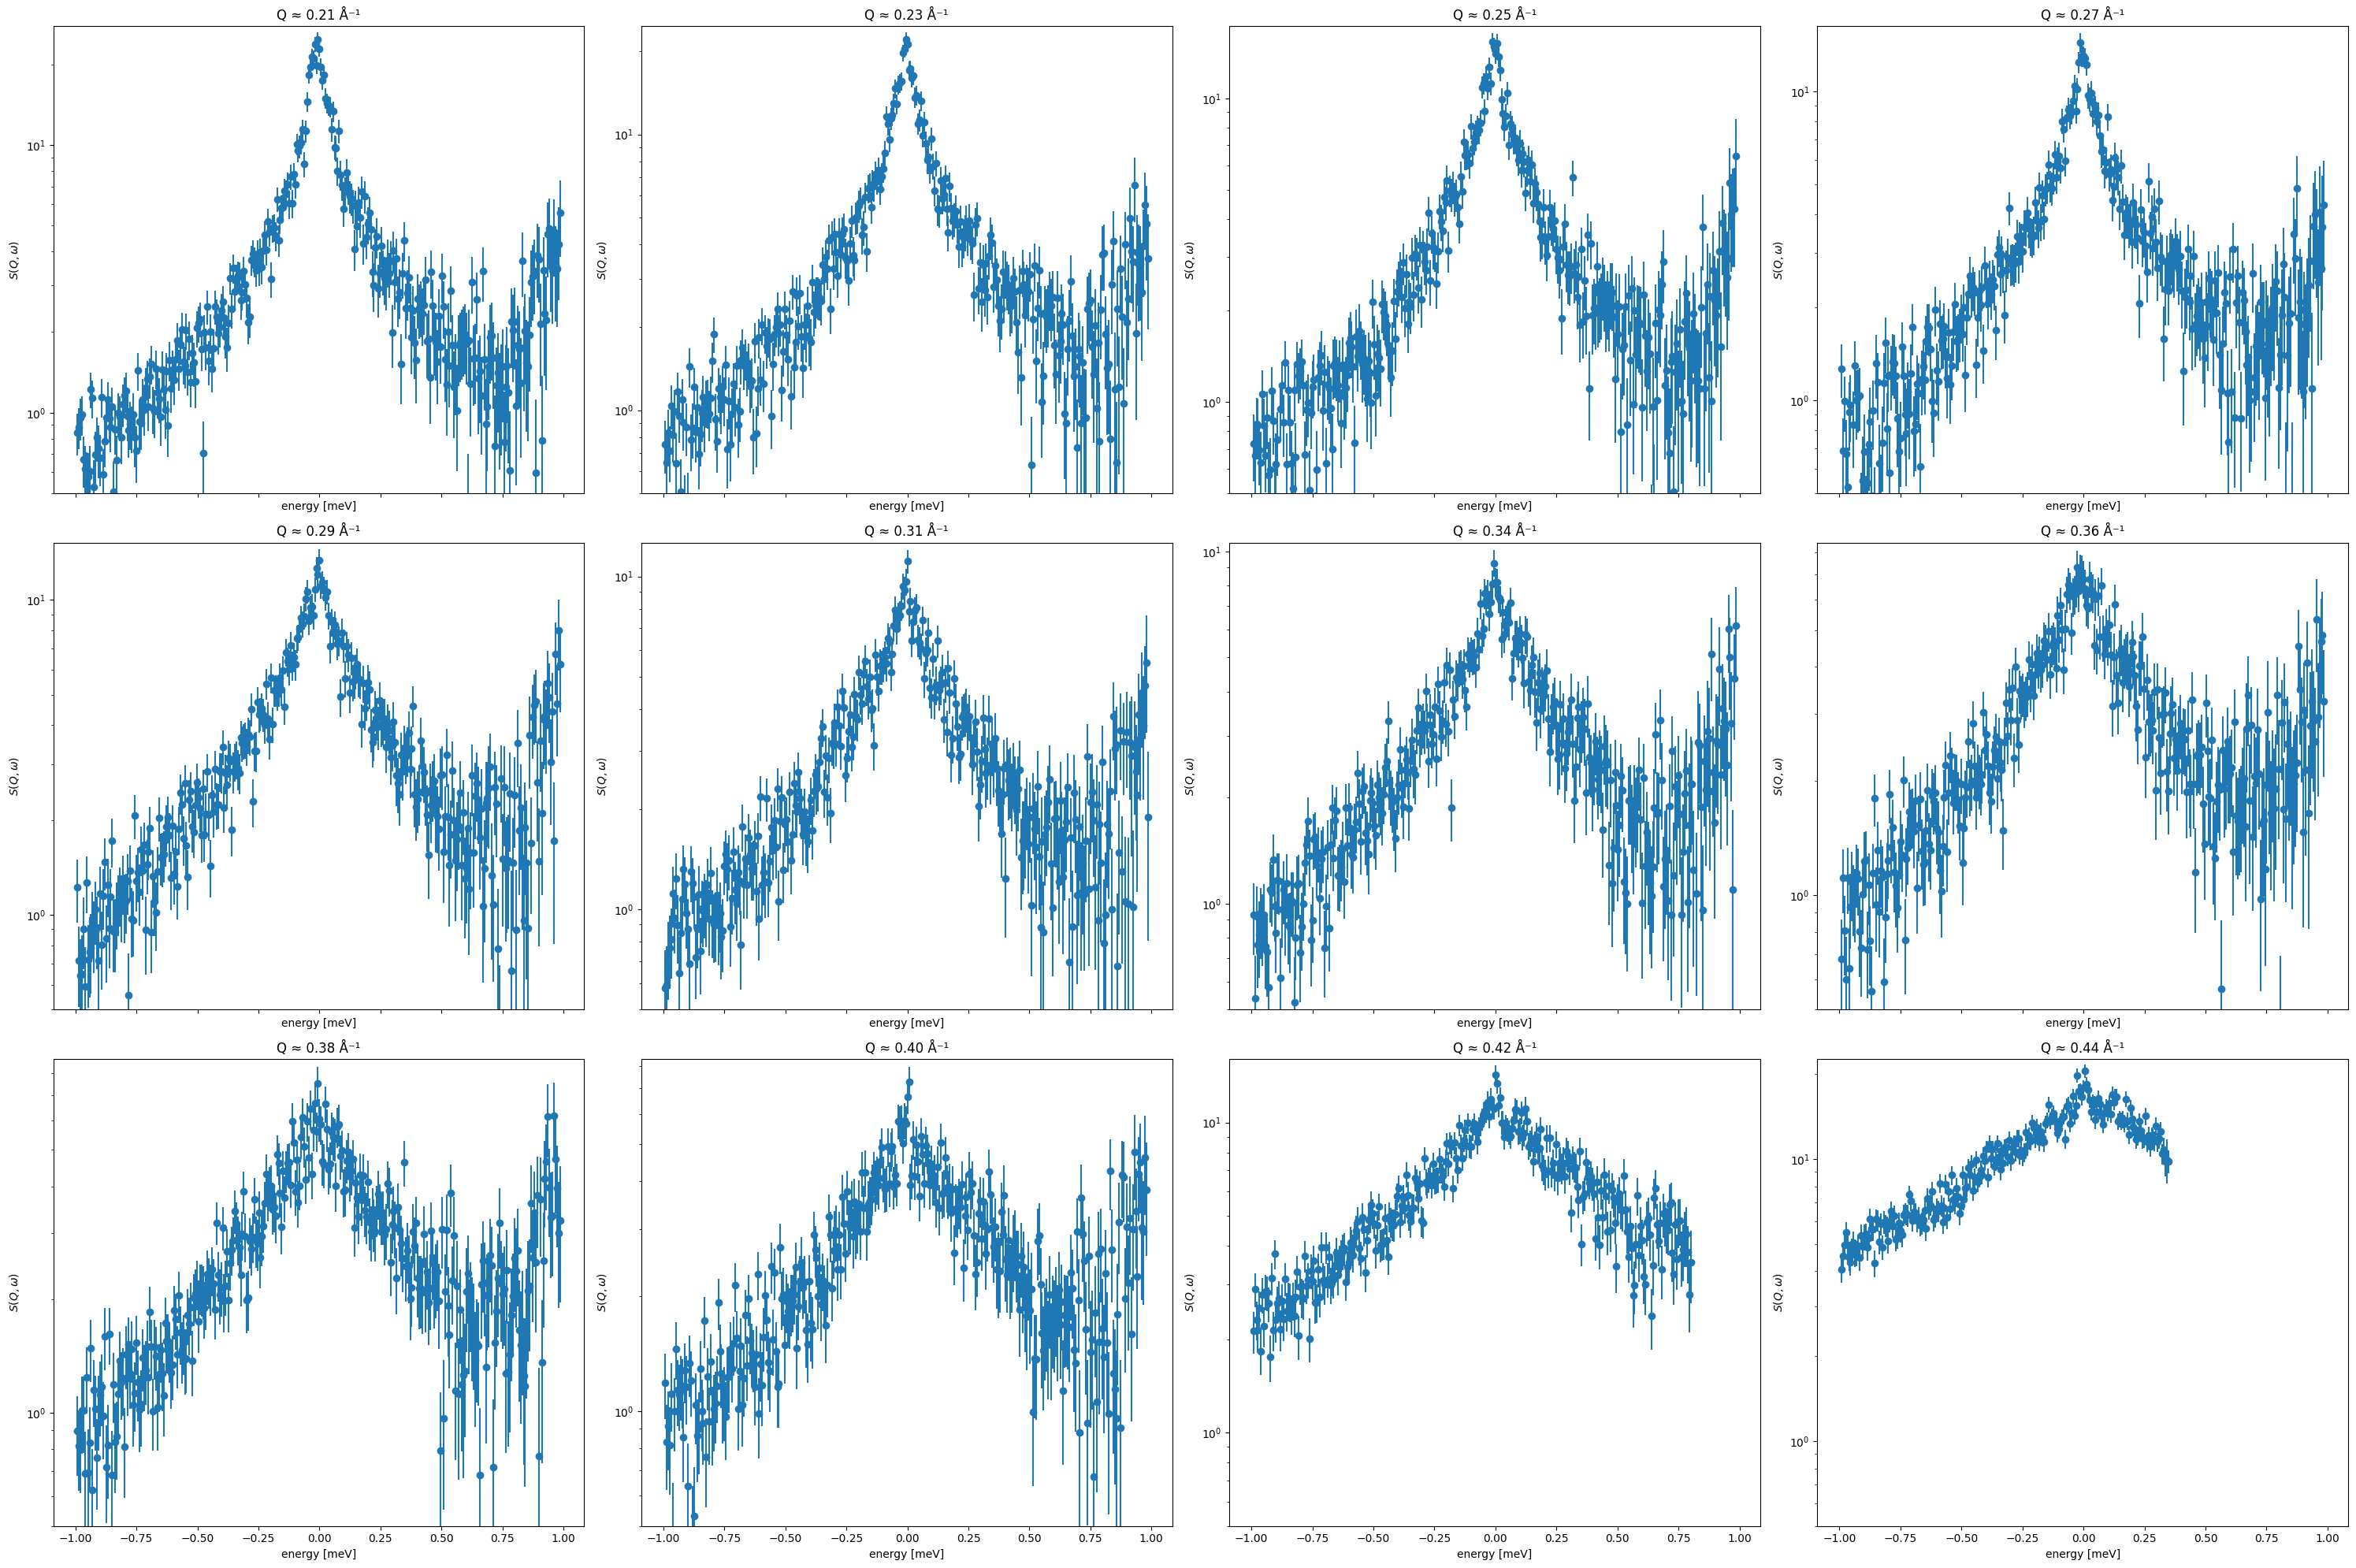

In [ ]:
q_start = 0.2 
q_end = 0.45
q_bins = sc.linspace('Q', q_start, q_end, 13, unit='1/angstrom')

# 2. group
binned_data = da_q.bin(Q=q_bins).hist()

# 3. plot
fig, axes = plt.subplots(3, 4, figsize=(30, 20), sharex=True)
axes = axes.flatten()

for i in range(12):
    # select bin
    slice_da = binned_data['Q', i]
    
    # Check if the slice is empty or contains excessively large error values.
    if slice_da.data.sum().value == 0:
        axes[i].text(0.5, 0.5, "No Data", ha='center')
        continue
    
    # plotting
    slice_da.plot(ax=axes[i])
    
    # title 
    q_center = (q_bins[i] + q_bins[i+1]) / 2
    axes[i].set_title(f"Q ≈ {q_center.value:.2f} Å⁻¹")
    axes[i].set_ylabel(r"$S(Q, \omega)$")
    
    axes[i].set_yscale('log')
    axes[i].set_ylim(bottom=0.5) # Setting a minimum value avoids negative value noise displayed on the log scale.
    
plt.tight_layout()
plt.show()